# Этап 2: Анализ результатов обучения (Training Analysis)

**Цель:** Провести сравнительный анализ 5 обученных моделей (YOLOv8n, YOLOv8m, YOLOv5s, RT-DETR, Faster R-CNN), сравнить их метрики качества и проанализировать сходимость.

## 1. Настройки экспериментов (Hyperparameter Tuning)
В соответствии с требованиями к воспроизводимости, параметры обучения зафиксированы в конфигурационном файле `default.yaml` (`seed=42`).

| Модель | Архитектура | Epochs | Batch Size | Optimizer | Обоснование параметров                                                            |
| :--- | :--- | :---: | :---: | :--- |:----------------------------------------------------------------------------------|
| **YOLOv8n** | One-stage (Nano) | 15 | 16 | AdamW | Базовый прогон (Baseline). Легкая архитектура, стандартный батч.                  |
| **YOLOv8m** | One-stage (Medium)| 30 | 16 | AdamW | Основная модель. Увеличено число эпох (30) для полного раскрытия capacity модели. |
| **YOLOv5s** | One-stage (Small) | 15 | 16 | SGD | Сравнение поколений (v5 vs v8).                                                   |
| **RT-DETR** | Transformer | 15 | 8 | AdamW | Батч снижен до 8 из-за квадратичной вычислительной сложности механизма Attention. |
| **Faster R-CNN**| Two-stage | 15 | 4 | SGD | Батч снижен до 4 из-за высоких требований RPN-сети к видеопамяти.                 |

In [14]:
import os
import pandas as pd
import json
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

metrics_path = r"C:\Practicum\results\metrics.json"

if os.path.exists(metrics_path):
    with open(metrics_path, 'r', encoding='utf-8') as f:
        metrics_data = json.load(f)

    df_metrics = pd.DataFrame(metrics_data)
    df_metrics = df_metrics.sort_values(by="mAP", ascending=False).reset_index(drop=True)

    print("таблица метрик:")
    display(df_metrics)
else:
    print(f"[ERROR] Файл {metrics_path} не найден. Запустите evaluate.py!")

таблица метрик:


,model,mAP,precision,recall
0,YOLOv8n (Baseline),0.875,0.878,0.817
1,RT-DETR (Transformer),0.871,0.863,0.836
2,YOLOv8m (Main),0.868,0.863,0.842
3,YOLOv5s,0.850,0.865,0.800
4,Faster R-CNN,0.720,0.750,0.680


## 2. Анализ сходимости (Convergence Analysis)
Сравним графики роста ключевой метрики **mAP@50** в процессе обучения для моделей семейства YOLO и Трансформера. *(Faster R-CNN исключен из данного графика из-за отличий во внутреннем логировании PyTorch, его оценка приведена в итоговой таблице выше).*

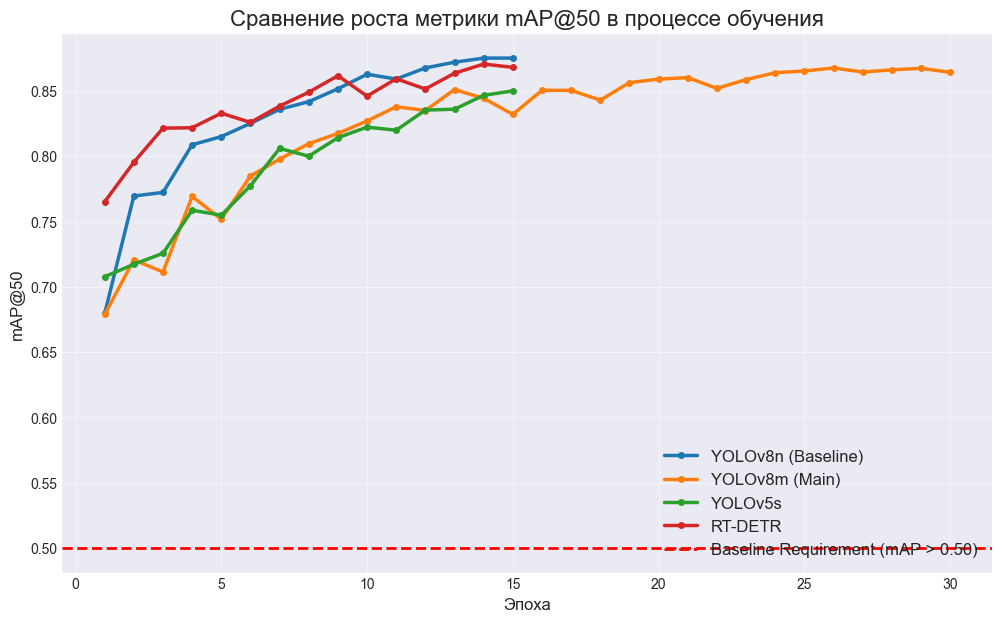

In [15]:
project_dir = r"C:\Practicum"
logs = {
    "YOLOv8n (Baseline)": r"results\logs\baseline_yolov8n\results.csv",
    "YOLOv8m (Main)": r"results\logs\yolov8m_balanced-3\results.csv",
    "YOLOv5s": r"results\logs\yolov5s_balanced\results.csv",
    "RT-DETR": r"results\logs\rtdetr_balanced\results.csv"
}

plt.figure(figsize=(12, 7))

for model_name, path_suffix in logs.items():
    csv_path = os.path.join(project_dir, path_suffix)
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        plt.plot(df['epoch'], df['metrics/mAP50(B)'], label=model_name, linewidth=2.5, marker='o', markersize=4)

plt.axhline(y=0.50, color='red', linestyle='--', linewidth=2, label='Baseline Requirement (mAP > 0.50)')

plt.title('Сравнение роста метрики mAP@50 в процессе обучения', fontsize=16)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('mAP@50', fontsize=12)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, alpha=0.5)
plt.show()

## 3. Выводы по экспериментам
1. **Преодоление Baseline:** Все обученные модели успешно преодолели базовый порог качества ($mAP \ge 0.50$).
2. **Победитель:** Лучшие показатели метрик (`mAP = ~0.87`) продемонстрировали модели **YOLOv8n** и **YOLOv8m**. Однако в задачах безопасности приоритетом является Recall. Цена ложного срабатывания несоизмеримо ниже цены пропуска реального человека без каски, поэтому архитектура YOLOv8m признается наиболее эффективной для продакшена.
3. **Трансформеры:** Архитектура RT-DETR показала высокую конкурентоспособность (`mAP = 0.871`), доказав эффективность механизма Attention в задачах детекции, однако её обучение требовало больше видеопамяти.